In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})
pd.options.display.float_format = '{:20,.2f}'.format
import os
import chardet

## Создание датасета

In [2]:
import re
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import spacy
# from sentence_transformers import SentenceTransformer
from nltk.corpus import stopwords
import nltk
from razdel import sentenize  # Import Razdel

In [4]:
# Загрузка данных
text = pd.read_excel('./new_data_almazov.xlsx') 

# Загрузка ресурсов
nltk.download('stopwords')
stopwords_ru = set(stopwords.words("russian"))
nlp = spacy.load("ru_core_news_sm", disable=['parser', 'ner']) # Disable unnecessary features to speed up lemmatization

def clean_and_lemmatize(text):
    """
    Cleans the segment: removes special characters, stop words and performs lemmatization.
    """
    text = str(text).lower()
    text = text.replace('_', ' ')
    # Leave only letters for lemmatization
    text = re.sub(r'[^а-яё ]', ' ', text)
    
    doc = nlp(text)
    # Lemmatization and stop word removal
    lemmas = [token.lemma_ for token in doc if token.text not in stopwords_ru and len(token.text) > 1]
    
    cleaned = " ".join(lemmas)
    return re.sub(r'\s+', ' ', cleaned).strip()

def segment_with_razdel(text):
    """
    Splits raw text into sentences using Razdel.
    Accounts for specific features, such as line breaks and periods.
    """
    if pd.isna(text) or str(text).strip() == "":
        return []
    
    # Razdel handles multi-line entries very well
    # We convert the sentenize generator into a list of strings
    return [sent.text.strip() for sent in sentenize(str(text))]

def process_pipeline(raw_text):
    """
    Полный цикл: Сегментация (Razdel) -> Очистка (spaCy)
    """
    # 1. Segmentation on raw data
    raw_segments = segment_with_razdel(raw_text)
    
    processed_segments = []
    for seg in raw_segments:
        # 2. Cleaning and lemmatization of each segment separately
        cleaned_seg = clean_and_lemmatize(seg)
        
        # Filter: leave only segments where more than 2 words remain after cleaning
        if len(cleaned_seg.split()) > 2:
            processed_segments.append(cleaned_seg)
            
    return processed_segments

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\emil_\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
print(f"Изначальное количество записей: {len(text)}")

text['processed_text'] = text['рекомендации общие'].apply(process_pipeline)

text_exploded = text.explode('processed_text')

text_exploded = text_exploded.dropna(subset=['processed_text'])
text_exploded = text_exploded[text_exploded['processed_text'] != '']

Изначальное количество записей: 44358


In [6]:
print(f"Количество сегментов после обработки: {len(text_exploded)}")
print(text_exploded[['processed_text']].head(10))

Количество сегментов после обработки: 63747
                                         processed_text
4413  режим нагрузка общий рекомендация контроль дав...
4415  режим нагрузка общий рекомендация ограничение ...
4415  пищевой волокно день предпочтительно овощ фрук...
4415                                  день порция фрукт
4415  день порция рыба раз неделя приём жирный рыба ...
4424  режим нагрузка общий рекомендация контроль дав...
4454  режим нагрузка общий рекомендация контроль ад ...
4514  режим нагрузка общий рекомендация контроль дав...
4559  режим нагрузка общий рекомендация контроль дав...
4567  режим нагрузка общий рекомендация контроль дав...


In [7]:
text_exploded = text_exploded[['Регистрационный номер', 'Номер эпизода', 'ФИО специалиста', 'Дата время выполнения', 'processed_text']]

In [8]:
text_exploded = text_exploded[text_exploded['processed_text'].apply(lambda x: len(x.split())) > 2]

In [9]:
text_exploded.head()

,Регистрационный номер,Номер эпизода,ФИО специалиста,Дата время выполнения,processed_text
4413,6612/A19,13654/А2019,Гордеева Мария Сергеевна,2019-03-06 15:00:00.000,режим нагрузка общий рекомендация контроль дав...
4415,5382/A19,NaN,Гордеева Мария Сергеевна,2019-03-06 15:30:00.000,режим нагрузка общий рекомендация ограничение ...
4415,5382/A19,NaN,Гордеева Мария Сергеевна,2019-03-06 15:30:00.000,пищевой волокно день предпочтительно овощ фрук...
4415,5382/A19,NaN,Гордеева Мария Сергеевна,2019-03-06 15:30:00.000,день порция фрукт
4415,5382/A19,NaN,Гордеева Мария Сергеевна,2019-03-06 15:30:00.000,день порция рыба раз неделя приём жирный рыба ...


In [10]:
text_exploded.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 63747 entries, 4413 to 44357
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Регистрационный номер  63747 non-null  object
 1   Номер эпизода          40850 non-null  object
 2   ФИО специалиста        63747 non-null  object
 3   Дата время выполнения  63747 non-null  object
 4   processed_text         63747 non-null  object
dtypes: object(5)
memory usage: 2.9+ MB


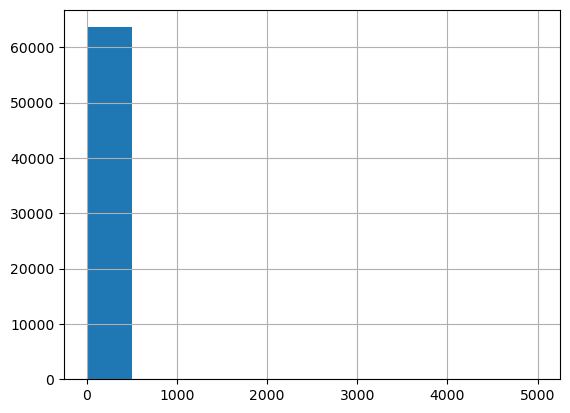

In [11]:
text_exploded['processed_text'].apply(len).hist(range=(0, 5000));

In [12]:
text_exploded.reset_index(drop=True, inplace=True)

In [13]:
text_exploded.to_csv('processed_text_almazov_natasha.csv', index=False)